In [8]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# carga data set

In [9]:
df = pl.scan_parquet('/home/montes/proyectos/paralela/polar_vrs_pandas/taxi_filtrado.parquet').collect()
print(f'Filas: {df.shape[0]:,}, Columnas: {df.shape[1]}')

Filas: 10,906,858, Columnas: 19


# estadisticas

In [10]:
df.describe()

statistic,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
str,f64,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1.0906858e7,"""10906858""","""10906858""",1.0906858e7,1.0906858e7,1.0906858e7,1.0906858e7,1.0906858e7,"""10906858""",1.0906858e7,1.0906858e7,1.0906858e7,1.0906858e7,1.0906858e7,1.0906858e7,1.0906858e7,1.0906858e7,1.0906858e7,1.0906858e7
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.535024,null,null,1.670847,4.648197,-72.818695,40.114943,1.03935,null,-72.886591,40.153152,1.347536,12.486929,0.313076,0.49767,1.750663,0.293345,0.299724,15.641395
"""std""",0.498772,null,null,1.324891,2981.095329,9.168964,5.051022,0.518631,null,8.900841,4.903456,0.49108,35.564004,0.415679,0.050467,2.623546,1.694572,0.012326,36.412802
"""min""",1.0,"""2016-01-01 00:00:00""","""2016-01-01 00:00:00""",0.0,0.0,-121.934288,0.0,1.0,"""N""",-121.933487,0.0,1.0,-957.6,-42.61,-0.5,-220.8,-17.4,-0.3,-958.4
"""25%""",1.0,null,null,1.0,1.0,-73.991508,40.736301,1.0,null,-73.991074,40.734806,1.0,6.5,0.0,0.5,0.0,0.0,0.3,8.3
"""50%""",2.0,null,null,1.0,1.67,-73.981377,40.753689,1.0,null,-73.979424,40.754131,1.0,9.0,0.0,0.5,1.26,0.0,0.3,11.62
"""75%""",2.0,null,null,2.0,3.08,-73.966103,40.768082,1.0,null,-73.96196,40.769619,2.0,14.0,0.5,0.5,2.32,0.0,0.3,17.16
"""max""",2.0,"""2016-01-31 23:59:59""","""2016-03-28 12:54:26""",9.0,8.00001e6,0.0,60.908756,99.0,"""Y""",0.0,60.908756,5.0,111270.85,648.87,89.7,998.14,980.15,0.3,111271.65


# Valores faltantes

shape: (1, 19)
┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ VendorID ┆ tpep_pick ┆ tpep_drop ┆ passenger ┆ … ┆ tip_amoun ┆ tolls_amo ┆ improveme ┆ total_amo │
│ ---      ┆ up_dateti ┆ off_datet ┆ _count    ┆   ┆ t         ┆ unt       ┆ nt_surcha ┆ unt       │
│ u32      ┆ me        ┆ ime       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ rge       ┆ ---       │
│          ┆ ---       ┆ ---       ┆ u32       ┆   ┆ u32       ┆ u32       ┆ ---       ┆ u32       │
│          ┆ u32       ┆ u32       ┆           ┆   ┆           ┆           ┆ u32       ┆           │
╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0        ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 0         ┆ 0         ┆ 0         ┆ 0         │
└──────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


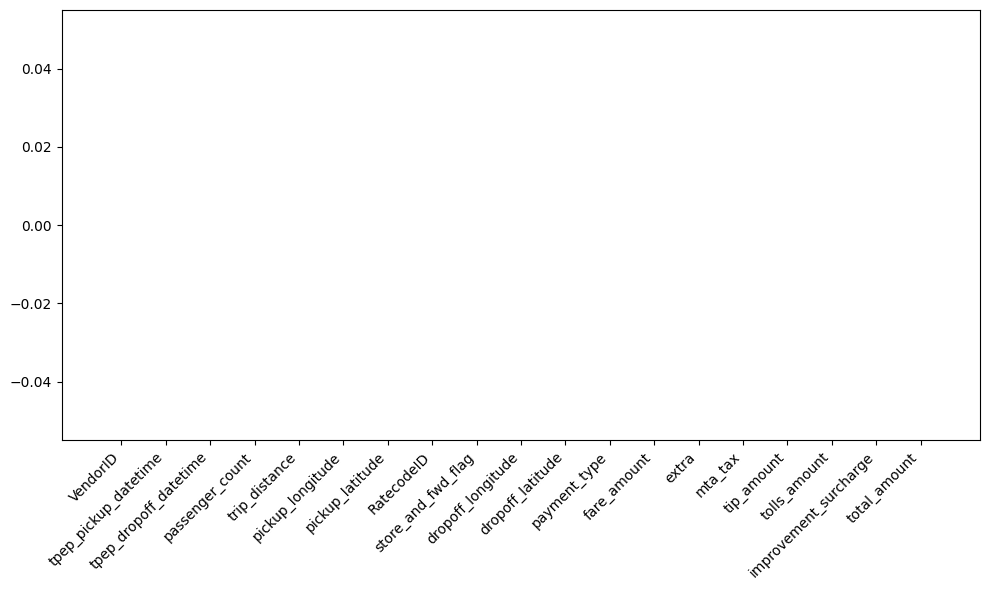

In [11]:
nulos = df.null_count()
print(nulos)

plt.figure(figsize=(10, 6))
plt.bar(nulos.columns, nulos.row(0))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Distribuciones

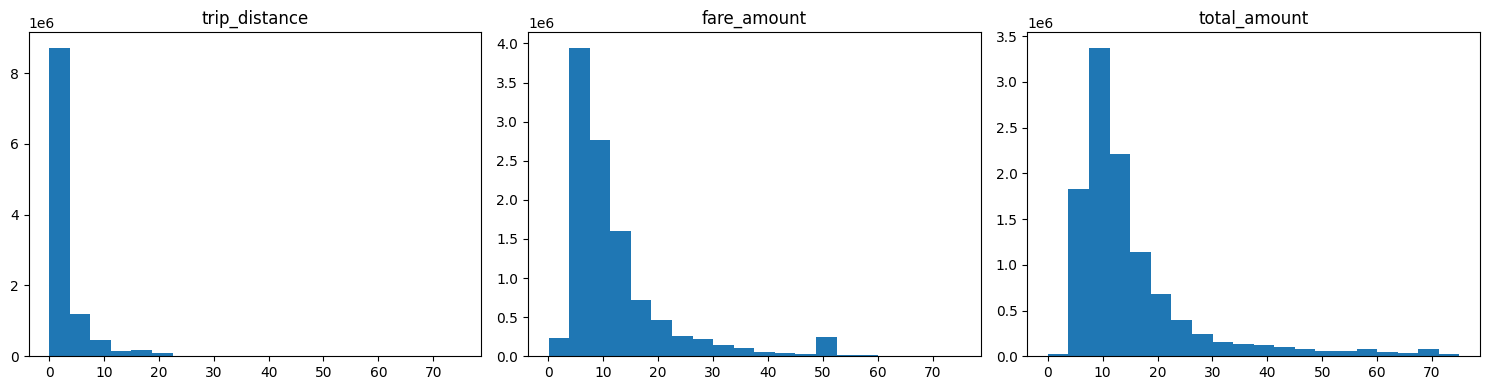

In [13]:
df = pl.read_parquet('/home/montes/proyectos/paralela/polar_vrs_pandas/taxi_filtrado.parquet')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['trip_distance', 'fare_amount', 'total_amount']):
    data = df.filter(pl.col(col).is_between(0, 75, closed='right'))[col].to_list()
    ax.hist(data, bins=20)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# Analisis Correlaciones

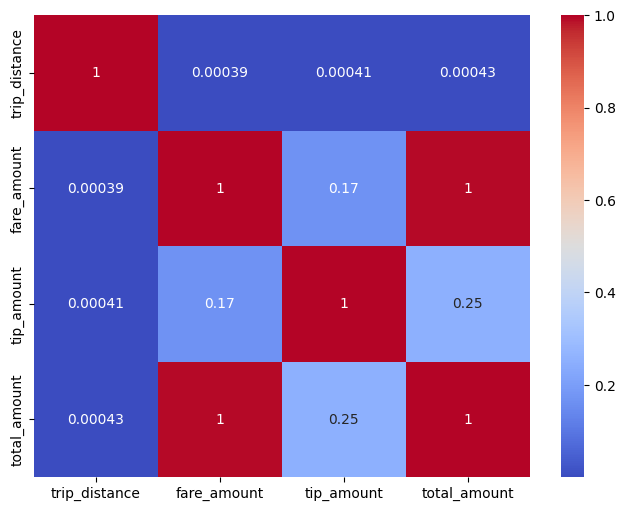

In [ ]:
cols_corr = ['trip_distance', 'fare_amount', 'tip_amount', 'total_amount']
corr = [[df.select(pl.corr(c1, c2)).item() for c2 in cols_corr] for c1 in cols_corr]

plt.figure(figsize=(8, 6))
sns.heatmap(corr, xticklabels=cols_corr, yticklabels=cols_corr, annot=True, cmap='coolwarm')
plt.show()